In [1]:
from data import CleanNumericDatasets
from reservoirs import CPRC
from circuits import CPCircuit
from ELM import QuantumELM
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from utility import Evaluator, regression_metrics, plot_actual_vs_pred

In [5]:
dim = 10
ds = CleanNumericDatasets(seed=3, scale=True)

X_train, X_test, y_train, y_test = ds.get("diabetes", sample_size=300, feature_size=dim)
print(ds.info())

{'name': 'diabetes', 'task': 'regression', 'source': 'sklearn', 'n_samples_requested': 300, 'n_features_requested': 10, 'n_samples_returned': 300, 'n_features_returned': 10, 'n_classes': None, 'feature_transform': 'none', 'scaler': 'standard', 'split': 'train_test_split', 'test_size': 0.2, 'random_state': 3, 'stratified': None, 'y_type': 'float64', 'X_dtype': 'float32', 'notes': 'sklearn dataset; transforms/scaling fit on train only.'}


In [6]:
# X_train, X_test, y_train, y_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

In [7]:
CP_params = [-np.pi/3, np.pi/6, -np.pi/9, np.pi/7, np.pi/9, -np.pi/7]
cprc = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel = True)

In [32]:
elm = QuantumELM(
        reservoir=cprc, 
        regularization=1e-8, 
        show_progress=True, 
        model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc',  or "ridge_classifier","logreg", "svc" for classification
        )
elm.fit(X_train, y_train)

ELM feature extraction: 100%|████████████| 240/240 [00:05<00:00, 47.36 sample/s]


In [33]:
predictions = elm.predict(X_test)
# rmse = np.sqrt(mean_squared_error(y_test, predictions))
# print("RMSE:", rmse)

ELM feature extraction: 100%|██████████████| 60/60 [00:01<00:00, 43.60 sample/s]


In [34]:
mets = regression_metrics(y_test, predictions)
print(mets)

{'RMSE': np.float64(73.84976978708308), 'MAE': 62.681296284993486, 'R2': 0.10902486338438644, 'NRMSE_std': np.float64(0.9439147930907701), 'NRMSE_range': np.float64(0.2656466539103698)}


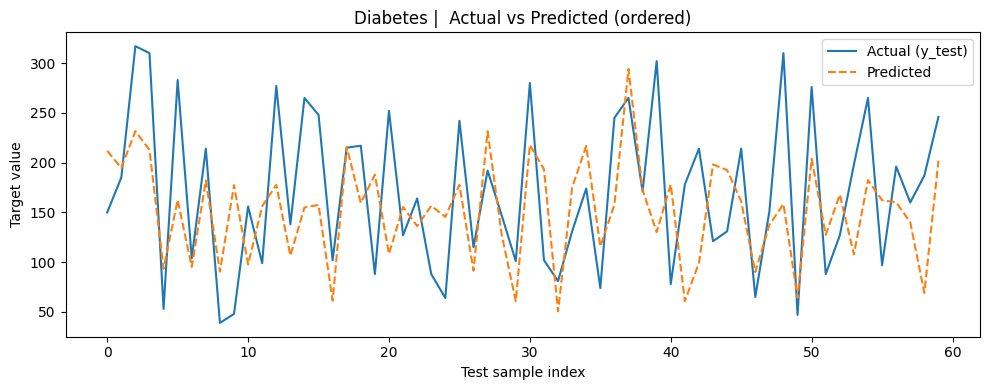

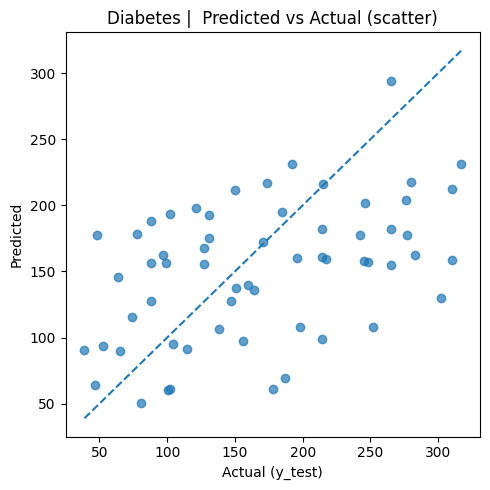

In [35]:
from utility import plot_actual_vs_pred
plot_actual_vs_pred(y_test, predictions, title_prefix="Diabetes | ")